<a href="https://colab.research.google.com/github/gyatun/code/blob/main/Project3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv("student_spending.csv")

In [ ]:
#Basic Inspection
df.head()

df.shape

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Unnamed: 0                1000 non-null   int64 
 1   age                       1000 non-null   int64 
 2   gender                    1000 non-null   object
 3   year_in_school            1000 non-null   object
 4   major                     1000 non-null   object
 5   monthly_income            1000 non-null   int64 
 6   financial_aid             1000 non-null   int64 
 7   tuition                   1000 non-null   int64 
 8   housing                   1000 non-null   int64 
 9   food                      1000 non-null   int64 
 10  transportation            1000 non-null   int64 
 11  books_supplies            1000 non-null   int64 
 12  entertainment             1000 non-null   int64 
 13  personal_care             1000 non-null   int64 
 14  technology               

,Unnamed: 0,age,monthly_income,financial_aid,tuition,housing,food,transportation,books_supplies,entertainment,personal_care,technology,health_wellness,miscellaneous
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,21.675000,1020.650000,504.771000,4520.395000,696.00600,252.642000,124.63700,174.761000,84.814000,60.699000,178.304000,114.310000,108.910000
std,288.819436,2.322664,293.841161,287.092575,860.657944,171.21862,86.949606,43.55799,72.404518,37.970451,22.898007,71.744441,49.591544,52.412221
min,0.000000,18.000000,501.000000,0.000000,3003.000000,401.00000,100.000000,50.00000,50.000000,20.000000,20.000000,50.000000,30.000000,20.000000
25%,249.750000,20.000000,770.750000,261.000000,3779.750000,538.75000,175.000000,88.00000,112.000000,54.000000,41.000000,114.000000,73.000000,63.750000
50%,499.500000,22.000000,1021.000000,513.000000,4547.500000,704.50000,255.000000,123.00000,175.000000,86.000000,62.000000,178.000000,115.000000,110.000000
75%,749.250000,24.000000,1288.250000,751.500000,5285.000000,837.25000,330.000000,162.25000,238.000000,116.000000,80.000000,241.000000,158.000000,153.000000
max,999.000000,25.000000,1500.000000,1000.000000,6000.000000,1000.00000,400.000000,200.00000,300.000000,150.000000,100.000000,300.000000,200.000000,200.000000


In [ ]:
##missing value check
df.isnull().sum()

,0
Unnamed: 0,0
age,0
gender,0
year_in_school,0
major,0
monthly_income,0
financial_aid,0
tuition,0
housing,0
food,0


In [ ]:
##duplicate records check
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
##drop unessesary columns
df.drop("Unnamed: 0",axis=1,inplace=True)

FEATURE ENGINEERING


In [ ]:
#Create Total Spending Feature-Provides overall spending behavior.
df["Total_Spending"] = (
      df["housing"]
    + df["food"]
    + df["transportation"]
    + df["books_supplies"]
    + df["entertainment"]
    + df["personal_care"]
    + df["technology"]
    + df["health_wellness"]
    + df["miscellaneous"]
)

In [ ]:

##Descriptive Statistics
df[
[
"monthly_income",
"housing",
"food",
"transportation",
"books_supplies",
"entertainment",
"personal_care",
"technology",
"health_wellness",
"miscellaneous",
"Total_Spending"
]
].describe()

,monthly_income,housing,food,transportation,books_supplies,entertainment,personal_care,technology,health_wellness,miscellaneous,Total_Spending
count,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1020.650000,696.00600,252.642000,124.63700,174.761000,84.814000,60.699000,178.304000,114.310000,108.910000,1795.08300
std,293.841161,171.21862,86.949606,43.55799,72.404518,37.970451,22.898007,71.744441,49.591544,52.412221,238.49789
min,501.000000,401.00000,100.000000,50.00000,50.000000,20.000000,20.000000,50.000000,30.000000,20.000000,1055.00000
25%,770.750000,538.75000,175.000000,88.00000,112.000000,54.000000,41.000000,114.000000,73.000000,63.750000,1622.00000
50%,1021.000000,704.50000,255.000000,123.00000,175.000000,86.000000,62.000000,178.000000,115.000000,110.000000,1784.00000
75%,1288.250000,837.25000,330.000000,162.25000,238.000000,116.000000,80.000000,241.000000,158.000000,153.000000,1968.50000
max,1500.000000,1000.00000,400.000000,200.00000,300.000000,150.000000,100.000000,300.000000,200.000000,200.000000,2453.00000


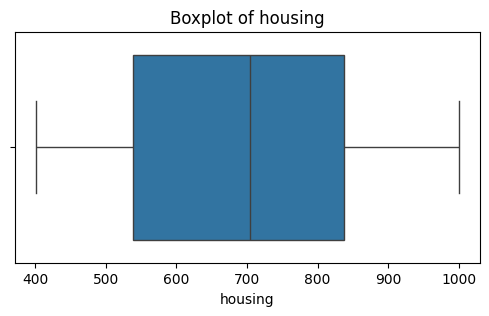

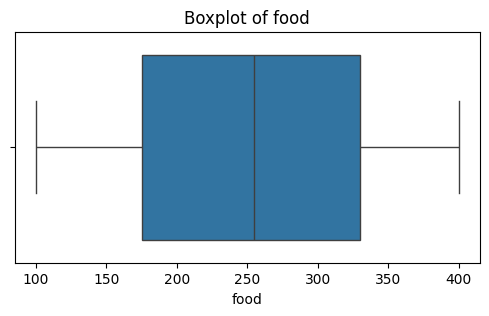

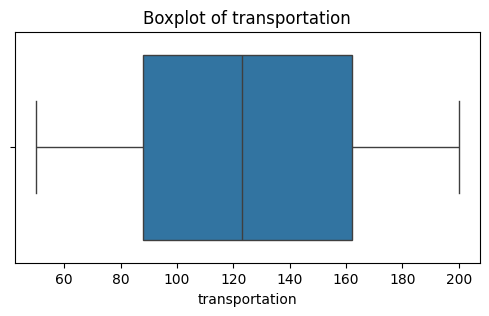

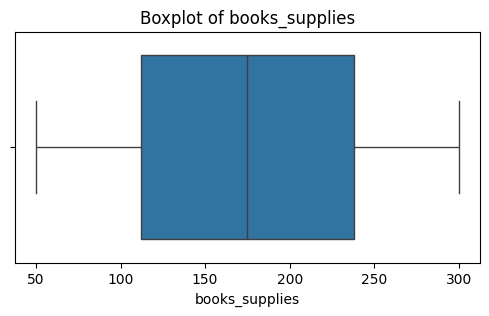

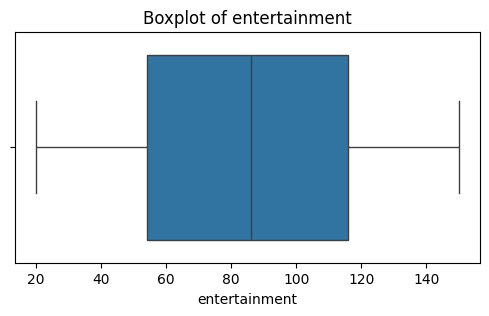

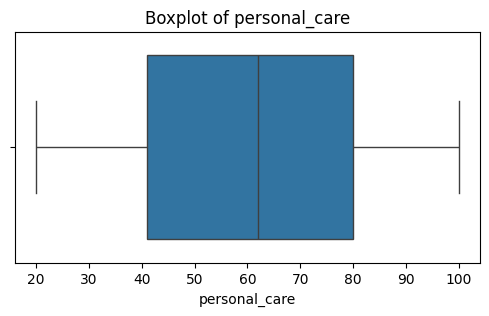

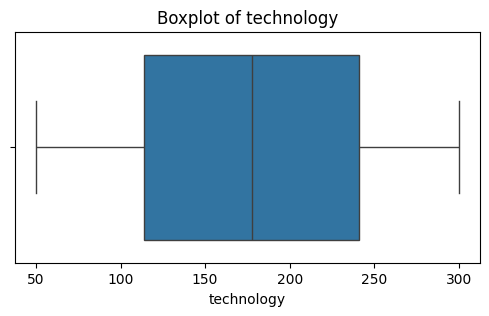

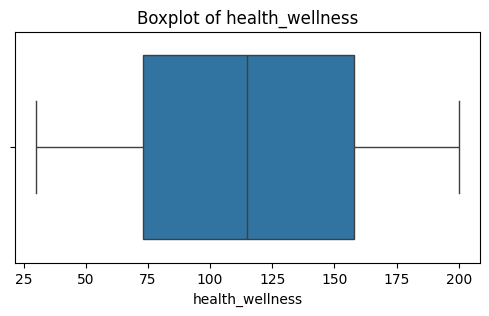

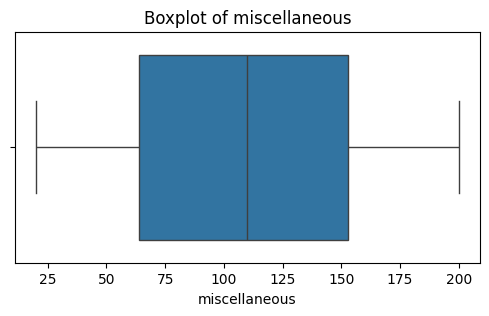

In [ ]:
#Box Plot Analysis---Use all spending columns
spending_cols = [
    "housing",
    "food",
    "transportation",
    "books_supplies",
    "entertainment",
    "personal_care",
    "technology",
    "health_wellness",
    "miscellaneous"
]

for col in spending_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
#Outlier Treatment (IQR)
for col in spending_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

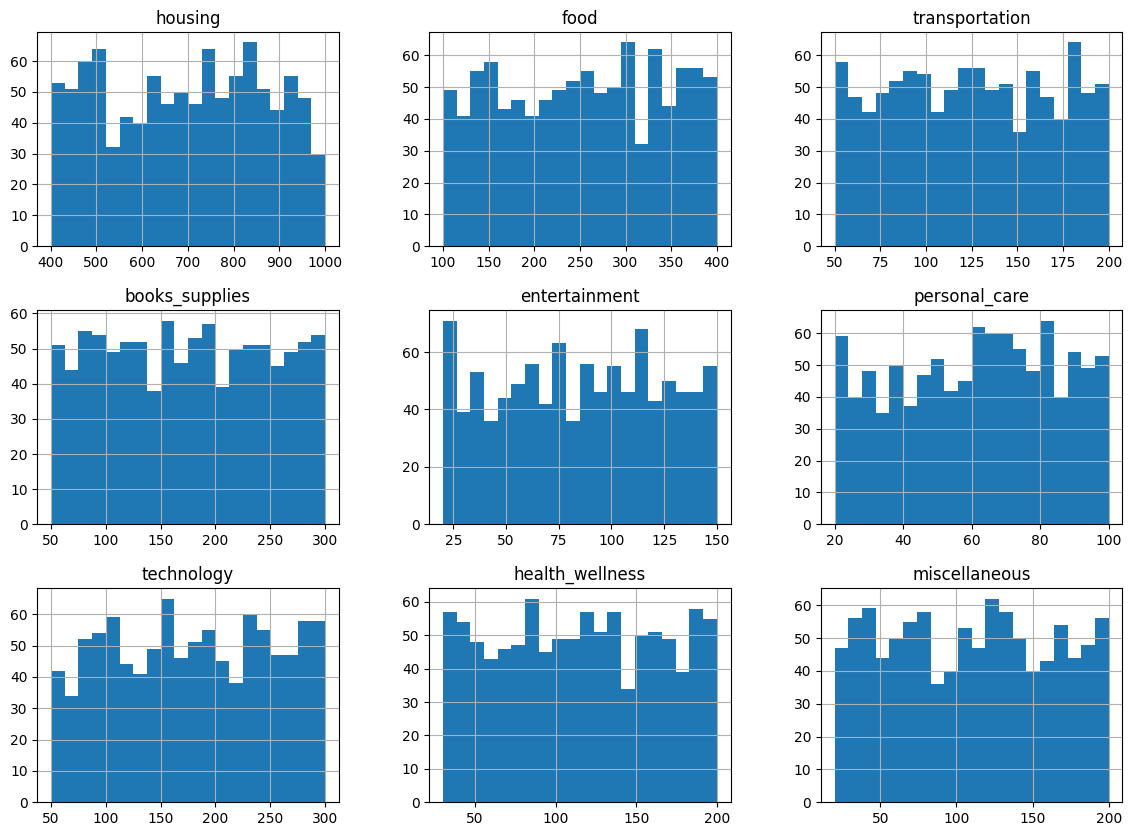

In [ ]:
#Distribution Analysis---Shows spending distribution patterns.
df[spending_cols].hist(
    figsize=(14,10),
    bins=20
)

plt.show()

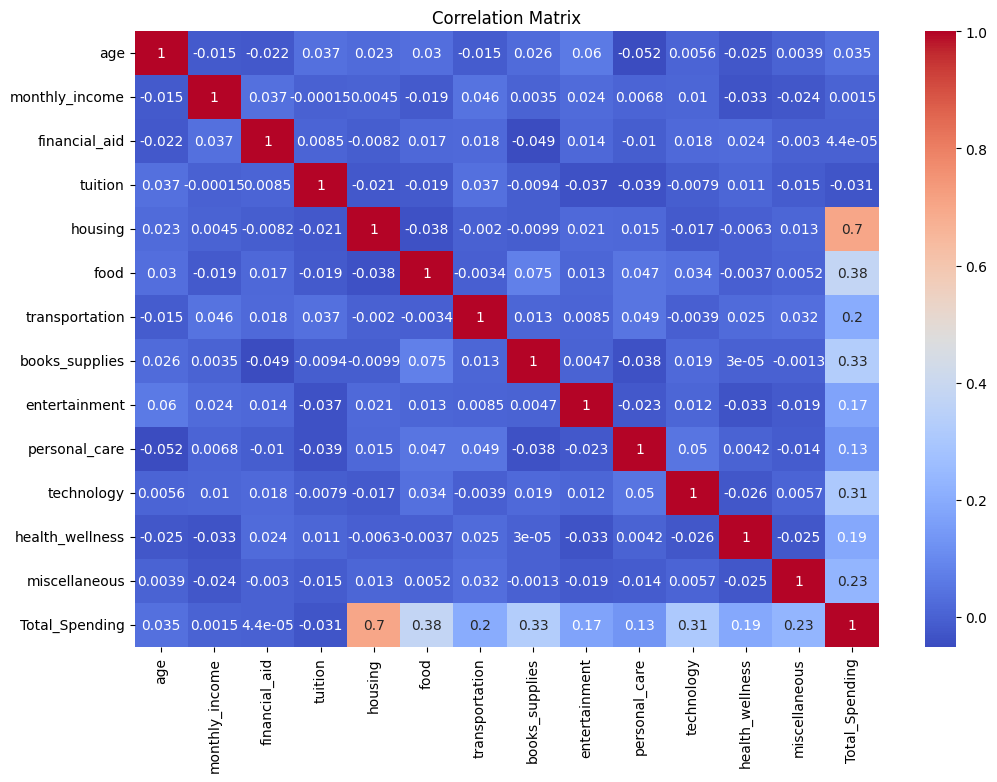

In [ ]:
##corelation heatmap--Identifies relationships between income and expenses.
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
##Feature Selection for Clustering
X = df[
[
"monthly_income",
"housing",
"food",
"transportation",
"books_supplies",
"entertainment",
"personal_care",
"technology",
"health_wellness",
"miscellaneous",
"Total_Spending"
]
]

In [ ]:
#Feature Scaling--normalize all feature 0-1
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

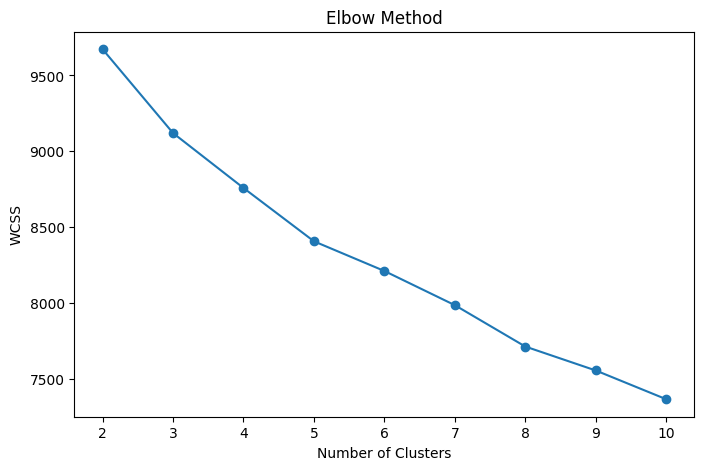

In [ ]:
#Elbow Method--finds the optimal number of clusters(k)
wcss = []

for i in range(2,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(2,11), wcss, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [ ]:
#Silhouette Score--measures it measures how good your clusters are.
for i in range(2,11):

    model = KMeans(
        n_clusters=i,
        random_state=42
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(f"K={i} : {score:.3f}")


K=2 : 0.111
K=3 : 0.085
K=4 : 0.076
K=5 : 0.077
K=6 : 0.070
K=7 : 0.071
K=8 : 0.077
K=9 : 0.075
K=10 : 0.076


In [ ]:
#Apply K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

In [ ]:
#Cluster Profiling--Groups all students according to their cluster labels.
cluster_summary = df.groupby(
    "Cluster"
).mean(numeric_only=True)

cluster_summary

,age,monthly_income,financial_aid,tuition,housing,food,transportation,books_supplies,entertainment,personal_care,technology,health_wellness,miscellaneous,Total_Spending
Cluster,,,,,,,,,,,,,,
0,21.775457,1003.323760,514.073107,4515.250653,850.587467,274.357702,132.966057,187.681462,89.825065,61.955614,189.778068,123.443864,116.770235,2027.365535
1,21.729167,1015.241071,489.660714,4518.247024,651.437500,205.863095,109.142857,137.309524,85.250000,53.214286,142.113095,102.625000,93.514881,1580.470238
2,21.473310,1050.733096,510.160142,4529.975089,538.604982,278.978648,131.811388,201.932384,77.462633,67.935943,205.939502,115.832740,116.604982,1735.103203


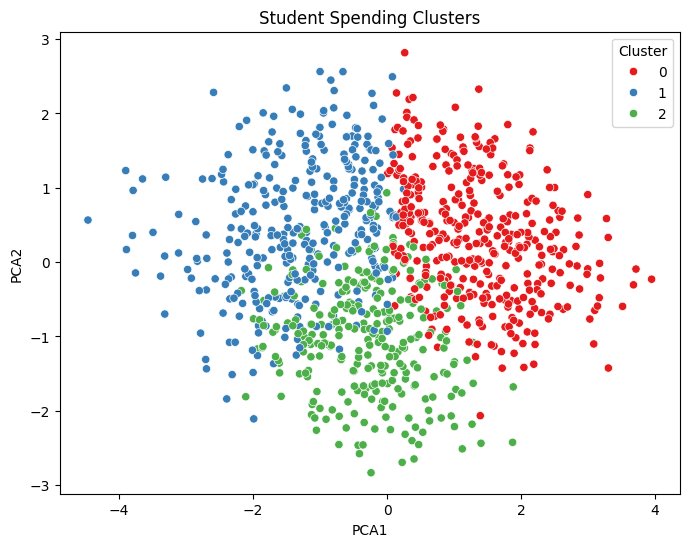

In [ ]:
#PCA Visualization
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

df["PCA1"] = pca_data[:,0]
df["PCA2"] = pca_data[:,1]

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    data=df,
    palette="Set1"
)

plt.title("Student Spending Clusters")
plt.show()

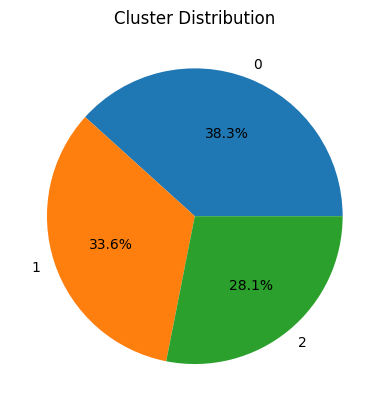

In [ ]:
#Cluster Distribution
df["Cluster"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Cluster Distribution")
plt.show()

In [ ]:
"""
Conclusion
Analyzed the spending behavior of university students using a dataset containing income and various expense categories.
Performed data preprocessing by checking for missing values, removing duplicates, and handling outliers using Box Plot Analysis and the IQR method.
Created a new feature, Total Spending, to better represent overall student expenditure.
Conducted Exploratory Data Analysis (EDA) using descriptive statistics, histograms, and correlation heatmaps to understand spending patterns.
Standardized the numerical features to ensure fair distance-based clustering.
Used the Elbow Method and Silhouette Score to determine the optimal number of clusters.
Applied K-Means Clustering to group students based on similarities in their spending habits.
Identified distinct student segments such as low-spending, moderate-spending, and high-spending groups.
Visualized the clusters using PCA, making the segmentation easier to interpret.
The findings provide valuable insights into student financial behavior and can help universities, financial institutions, and businesses better understand student spending patterns.

Future Scope
Include additional factors such as academic performance, savings, and part-time income.
Experiment with advanced clustering techniques such as Hierarchical Clustering and DBSCAN.
Develop a recommendation system to provide personalized budgeting suggestions for students.
Use real-time financial data to monitor and analyze spending trends over time.

"""